# Telco Customer Churn — Modeling & Evaluation

**Author:** Allison Schiltz\

**Objectives**:
- Build two models to predict `Churn`:
    - For both models: **Class weights** will be used adjust for imbalanced data and **regularization** will be used to prevent overfitting.
    - **Logistic Regression** with regularizataion as a baseline and for interpretability. A baseline model helps determine whether a more complex model adds value. 
    - **Gradient Boosted Trees** using LightGBM for higher predictive power
    - **Optuna** will be using for hyperparameter tuning and cross-validation
- **Strategy**: 
    - Use a train/test split strategy with cross-validation (CV) plus a final holdout set.
    - Perform cross-validation on the training data to tune hyperparameters.
    - Evaluate the final model on the untouched test set (holdout) for an unbiased performance estimate.
- Prioritize **recall ≥ 0.70** and **ROC-AUC > 0.75**
    - **Recall** to identify as many customers at risk of churning as possible (minimizing false negatives). This is important in churn scenarios, where missing a potential churner can be costly for the business.
    - **ROC-AUC** to measure the model’s overall discriminative power to distinguish between churners and non-churners across all thresholds.

## 0. Environment & Imports

In [2]:

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import optuna
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import recall_score, roc_auc_score, precision_score, confusion_matrix, roc_curve, precision_recall_curve
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

from optuna.integration import LightGBMTuner
import lightgbm as lgb

SEED = 42
np.random.seed(SEED)

In [3]:
import sys
print(sys.executable)

/Users/Allison/Code/.venv/bin/python


## 1. Load Data
- Load combined, preprocessed features and target labels needed for modeling.
- Load column-role manifest (ID, target, numeric, categorical, booleans)

In [4]:
# Load Training features
X_train_final = pd.read_csv('../data/processed/X_train_final.csv')
# Load Training target
y_train = pd.read_csv('../data/processed/y_train.csv')

# Load Test features
X_test_final = pd.read_csv('../data/processed/X_test_final.csv')
# Load Test target
y_test = pd.read_csv('../data/processed/y_test.csv')

# Load column role manifest
column_roles = pd.read_csv('../references/telco_column_role_manifest.csv')

In [5]:
# Extract target column

y_train = y_train['Churn']
y_test = y_test['Churn']

In [6]:
print(X_train_final.shape)
print(y_train.shape, '\n')

print(X_test_final.shape)
print(y_test.shape)

(5625, 41)
(5625,) 

(1407, 41)
(1407,)


In [7]:
# print(X_train_final.head())
# print(X_test_final.head())
print(y_train.head())
print(y_test.head(), '\n')
print('X_train_final dtypes:', X_train_final.dtypes, '\n')
print('X_test_final dtypes:', X_test_final.dtypes, '\n')

0    0
1    0
2    0
3    0
4    0
Name: Churn, dtype: int64
0    0
1    0
2    0
3    1
4    0
Name: Churn, dtype: int64 

X_train_final dtypes: Unnamed: 0                                 int64
tenure                                   float64
MonthlyCharges                           float64
TotalCharges                             float64
total_services_eng                       float64
gender_Male                                 bool
SeniorCitizen_Yes                           bool
Partner_Yes                                 bool
Dependents_Yes                              bool
PhoneService_Yes                            bool
MultipleLines_No phone service              bool
MultipleLines_Yes                           bool
InternetService_Fiber optic                 bool
InternetService_No                          bool
OnlineSecurity_No internet service          bool
OnlineSecurity_Yes                          bool
OnlineBackup_No internet service            bool
OnlineBackup_Yes     

In [8]:
# Clean feature names for LightGBM compatibility
import re

def clean_feature_names(df):
    clean_cols = [re.sub(r'[\[\]{}:,"\s]', '_', str(col)) for col in df.columns]
    df.columns = clean_cols
    return df

X_train_final = clean_feature_names(X_train_final)
X_test_final = clean_feature_names(X_test_final)
print("Cleaned feature names for LightGBM.")

Cleaned feature names for LightGBM.


## 2. Baselines
1. Majority-class baseline:
- Predict the most frequent class for all cases (e.g., always predict "No Churn").
- Calculate and record metrics: recall, precision, ROC-AUC, PR-AUC. This sets a minimum performance bar.
2. Logistic regression baseline (with regularization):
- Train a logistic regression model using default or simple regularization (e.g., L2 penalty, class_weight="balanced").
- Evaluate on the validation or test set.
- Record the same metrics: recall, precision, ROC-AUC, PR-AUC.


In [9]:
# Majority class baseline
from sklearn.dummy import DummyClassifier

# Instantiate and fit dummy classifier
dummy = DummyClassifier(strategy="most_frequent", random_state=SEED)
dummy.fit(X_train_final, y_train.values.ravel())

# Predict class labels and class probabilities
y_pred_dummy = dummy.predict(X_test_final)
y_proba_dummy = dummy.predict_proba(X_test_final)[:, 1]

# Calculate and print metrics
print("Recall:", recall_score(y_test, y_pred_dummy))
print("Precision:", precision_score(y_test, y_pred_dummy))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_dummy))

Recall: 0.0
Precision: 0.0
ROC-AUC: 0.5


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [10]:
# Logistic Regression Model with Regularization, Hyperparameter Tuning, and Class Weighting

# Define parameter grid for hyperparameter tuning
param_grid = {
    'C': [0.01, 0.1, 1, 10],           # Regularization strength
    'penalty': ['l2', 'l1'],                 # L1 and L2 regularization types
    'solver': ['liblinear'],               # 'liblinear' supports L1 and L2
    'class_weight': ['balanced']       # Handle class imbalance
}

# Set up logistic regression and grid search
logreg = LogisticRegression(max_iter=1000, random_state=SEED)
grid = GridSearchCV(logreg, param_grid, scoring='recall', cv=5, n_jobs=-1)

# Fit on training data
grid.fit(X_train_final, y_train if isinstance(y_train, pd.Series) else y_train)

# Best model
best_logreg = grid.best_estimator_



Python(66043) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(66044) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(66045) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(66046) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(66047) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(66048) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(66049) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(66050) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(66051) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(66052) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(66053) Malloc

In [20]:
print(best_logreg)

LogisticRegression(C=0.1, class_weight='balanced', max_iter=1000,
                   random_state=42, solver='liblinear')


In [11]:
# Predict and evaluate
y_pred_logreg = best_logreg.predict(X_test_final)
y_proba_logreg = best_logreg.predict_proba(X_test_final)[:, 1]

print("Best parameters:", grid.best_params_)
print("Recall:", recall_score(y_test if isinstance(y_test, pd.Series) else y_test, y_pred_logreg))
print("Precision:", precision_score(y_test if isinstance(y_test, pd.Series) else y_test, y_pred_logreg))
print("ROC-AUC:", roc_auc_score(y_test if isinstance(y_test, pd.Series) else y_test, y_proba_logreg))


Best parameters: {'C': 0.1, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'liblinear'}
Recall: 0.7887700534759359
Precision: 0.49413735343383586
ROC-AUC: 0.8371028777611547


## 4. Advanced Models
- Tree-based gradient boosting with LightGBM
- Hyperparameter tuning (Oputuna) with cross-validation
- Early stopping / model selection criteria

In [12]:
# LightGBM Model with Optuna Hyperparameter Tuning and Cross-Validation

import optuna.integration.lightgbm as lgb_optuna
import lightgbm as lgb

# Prepare data for LightGBM (no need for label column in features)
X = X_train_final
y = y_train

# Set up Optuna LightGBM parameters
params = {
    'objective': 'binary',
    'metric': 'auc',
    'verbosity': -1,
    'boosting_type': 'gbdt',
    'class_weight': 'balanced',
}

callbacks = [lgb.early_stopping(stopping_rounds=50, min_delta=0.0)]


# Run Optuna hyperparameter tuning with cross-validation
optuna_lgbm = lgb_optuna.LightGBMTunerCV(
    params,
    lgb.Dataset(X, label=y),
    folds=None,  # None uses StratifiedKFold by default
    show_progress_bar=True,
    num_boost_round=1000,
    seed=SEED,
    nfold=5,
    callbacks=callbacks
)
optuna_lgbm.run()


[I 2026-01-10 14:12:05,187] A new study created in memory with name: no-name-44ce2718-b235-455f-b24d-49eaa6b0e7c8
feature_fraction, val_score: -inf:   0%|          | 0/7 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds


feature_fraction, val_score: 0.844429:  14%|#4        | 1/7 [00:00<00:05,  1.11it/s]

Early stopping, best iteration is:
[25]	valid's auc: 0.844429 + 0.00469507
Training until validation scores don't improve for 50 rounds


feature_fraction, val_score: 0.845929:  29%|##8       | 2/7 [00:01<00:03,  1.65it/s]

Early stopping, best iteration is:
[21]	valid's auc: 0.845929 + 0.00456528
Training until validation scores don't improve for 50 rounds


feature_fraction, val_score: 0.847109:  43%|####2     | 3/7 [00:01<00:02,  1.95it/s]

Early stopping, best iteration is:
[22]	valid's auc: 0.847109 + 0.00614192
Training until validation scores don't improve for 50 rounds


feature_fraction, val_score: 0.847109:  57%|#####7    | 4/7 [00:02<00:01,  2.10it/s]

Early stopping, best iteration is:
[21]	valid's auc: 0.846445 + 0.00599438
Training until validation scores don't improve for 50 rounds


feature_fraction, val_score: 0.847660:  71%|#######1  | 5/7 [00:02<00:01,  1.92it/s]

Early stopping, best iteration is:
[24]	valid's auc: 0.84766 + 0.00508612
Training until validation scores don't improve for 50 rounds


feature_fraction, val_score: 0.847660:  86%|########5 | 6/7 [00:03<00:00,  2.13it/s]

Early stopping, best iteration is:
[19]	valid's auc: 0.844421 + 0.00433494
Training until validation scores don't improve for 50 rounds


feature_fraction, val_score: 0.847660: 100%|##########| 7/7 [00:03<00:00,  1.94it/s]


Early stopping, best iteration is:
[36]	valid's auc: 0.844399 + 0.00396617


num_leaves, val_score: 0.847660:   0%|          | 0/20 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.848915:   5%|5         | 1/20 [00:00<00:06,  2.94it/s]

Early stopping, best iteration is:
[24]	valid's auc: 0.848915 + 0.0046718
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.848915:  10%|#         | 2/20 [00:00<00:05,  3.05it/s]

Early stopping, best iteration is:
[24]	valid's auc: 0.848766 + 0.00443699
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.849151:  15%|#5        | 3/20 [00:01<00:06,  2.70it/s]

Early stopping, best iteration is:
[26]	valid's auc: 0.849151 + 0.00416386
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.849151:  20%|##        | 4/20 [00:02<00:11,  1.34it/s]

Early stopping, best iteration is:
[24]	valid's auc: 0.842715 + 0.00466851
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.849744:  25%|##5       | 5/20 [00:02<00:08,  1.67it/s]

Early stopping, best iteration is:
[37]	valid's auc: 0.849744 + 0.00288089
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.849744:  30%|###       | 6/20 [00:03<00:07,  2.00it/s]

Early stopping, best iteration is:
[24]	valid's auc: 0.849527 + 0.00433322
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.849744:  35%|###5      | 7/20 [00:04<00:08,  1.45it/s]

Early stopping, best iteration is:
[20]	valid's auc: 0.842878 + 0.00562737
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.849744:  40%|####      | 8/20 [00:04<00:08,  1.36it/s]

Early stopping, best iteration is:
[21]	valid's auc: 0.8424 + 0.00621644
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.849744:  45%|####5     | 9/20 [00:05<00:07,  1.39it/s]

Early stopping, best iteration is:
[24]	valid's auc: 0.844826 + 0.00506146
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.849744:  50%|#####     | 10/20 [00:06<00:08,  1.15it/s]

Early stopping, best iteration is:
[24]	valid's auc: 0.842715 + 0.00466851
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.849744:  55%|#####5    | 11/20 [00:07<00:07,  1.22it/s]

Early stopping, best iteration is:
[20]	valid's auc: 0.845111 + 0.00475195
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.849744:  60%|######    | 12/20 [00:08<00:07,  1.02it/s]

Early stopping, best iteration is:
[24]	valid's auc: 0.841903 + 0.00460082
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.849958:  65%|######5   | 13/20 [00:09<00:05,  1.27it/s]

Early stopping, best iteration is:
[89]	valid's auc: 0.849958 + 0.00433803
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.849958:  70%|#######   | 14/20 [00:10<00:04,  1.25it/s]

Early stopping, best iteration is:
[25]	valid's auc: 0.845264 + 0.00548697
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.849958:  75%|#######5  | 15/20 [00:11<00:05,  1.08s/it]

Early stopping, best iteration is:
[35]	valid's auc: 0.849652 + 0.00476768
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.849958:  80%|########  | 16/20 [00:12<00:03,  1.03it/s]

Early stopping, best iteration is:
[53]	valid's auc: 0.849355 + 0.00426994
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.849958:  85%|########5 | 17/20 [00:13<00:02,  1.04it/s]

Early stopping, best iteration is:
[18]	valid's auc: 0.846836 + 0.00454266
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.849958:  90%|######### | 18/20 [00:14<00:01,  1.06it/s]

Early stopping, best iteration is:
[18]	valid's auc: 0.847452 + 0.00504867
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.850700:  95%|#########5| 19/20 [00:15<00:01,  1.10s/it]

Early stopping, best iteration is:
[290]	valid's auc: 0.8507 + 0.00435556
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.850700: 100%|##########| 20/20 [00:17<00:00,  1.14it/s]


Early stopping, best iteration is:
[24]	valid's auc: 0.842343 + 0.00426947


bagging, val_score: 0.850700:   0%|          | 0/10 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.850700:  10%|#         | 1/10 [00:00<00:05,  1.79it/s]

Early stopping, best iteration is:
[178]	valid's auc: 0.850311 + 0.00500849
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.850700:  20%|##        | 2/10 [00:01<00:05,  1.50it/s]

Early stopping, best iteration is:
[173]	valid's auc: 0.850014 + 0.00490445
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.850700:  30%|###       | 3/10 [00:01<00:03,  1.80it/s]

Early stopping, best iteration is:
[167]	valid's auc: 0.849616 + 0.00481815
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.850700:  40%|####      | 4/10 [00:02<00:03,  1.90it/s]

Early stopping, best iteration is:
[165]	valid's auc: 0.850263 + 0.00512556
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.850700:  50%|#####     | 5/10 [00:02<00:02,  1.79it/s]

Early stopping, best iteration is:
[172]	valid's auc: 0.850133 + 0.0046476
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.850700:  60%|######    | 6/10 [00:03<00:02,  1.86it/s]

Early stopping, best iteration is:
[165]	valid's auc: 0.850379 + 0.00436323
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.850700:  70%|#######   | 7/10 [00:03<00:01,  1.77it/s]

Early stopping, best iteration is:
[231]	valid's auc: 0.850579 + 0.00465836
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.851156:  80%|########  | 8/10 [00:04<00:01,  1.84it/s]

Early stopping, best iteration is:
[188]	valid's auc: 0.851156 + 0.00436335
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.851156:  90%|######### | 9/10 [00:04<00:00,  1.88it/s]

Early stopping, best iteration is:
[188]	valid's auc: 0.850425 + 0.00458589
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.851156: 100%|##########| 10/10 [00:05<00:00,  1.78it/s]


Early stopping, best iteration is:
[238]	valid's auc: 0.850441 + 0.0045595


feature_fraction_stage2, val_score: 0.851156:   0%|          | 0/3 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds


feature_fraction_stage2, val_score: 0.851156:  33%|###3      | 1/3 [00:00<00:01,  1.81it/s]

Early stopping, best iteration is:
[187]	valid's auc: 0.851007 + 0.00448397
Training until validation scores don't improve for 50 rounds


feature_fraction_stage2, val_score: 0.851156:  67%|######6   | 2/3 [00:01<00:00,  1.86it/s]

Early stopping, best iteration is:
[187]	valid's auc: 0.850851 + 0.00459716
Training until validation scores don't improve for 50 rounds


feature_fraction_stage2, val_score: 0.851156: 100%|##########| 3/3 [00:01<00:00,  1.91it/s]


Early stopping, best iteration is:
[188]	valid's auc: 0.851016 + 0.00436985


regularization_factors, val_score: 0.851156:   0%|          | 0/20 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.851156:   5%|5         | 1/20 [00:00<00:09,  1.95it/s]

Early stopping, best iteration is:
[188]	valid's auc: 0.851156 + 0.00436335
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.851156:  10%|#         | 2/20 [00:01<00:09,  1.93it/s]

Early stopping, best iteration is:
[188]	valid's auc: 0.851156 + 0.00436345
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.851156:  15%|#5        | 3/20 [00:01<00:09,  1.79it/s]

Early stopping, best iteration is:
[188]	valid's auc: 0.851156 + 0.00436335
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.851156:  20%|##        | 4/20 [00:02<00:08,  1.79it/s]

Early stopping, best iteration is:
[188]	valid's auc: 0.851156 + 0.00436335
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.851156:  25%|##5       | 5/20 [00:02<00:08,  1.71it/s]

Early stopping, best iteration is:
[188]	valid's auc: 0.851156 + 0.00436335
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.851156:  30%|###       | 6/20 [00:03<00:08,  1.60it/s]

Early stopping, best iteration is:
[188]	valid's auc: 0.851156 + 0.00436335
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.851156:  35%|###5      | 7/20 [00:04<00:08,  1.55it/s]

Early stopping, best iteration is:
[188]	valid's auc: 0.851156 + 0.00436335
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.851156:  40%|####      | 8/20 [00:04<00:07,  1.59it/s]

Early stopping, best iteration is:
[188]	valid's auc: 0.851156 + 0.00436345
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.851156:  45%|####5     | 9/20 [00:05<00:06,  1.64it/s]

Early stopping, best iteration is:
[188]	valid's auc: 0.851007 + 0.0043607
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.851156:  50%|#####     | 10/20 [00:05<00:06,  1.65it/s]

Early stopping, best iteration is:
[188]	valid's auc: 0.851156 + 0.00436335
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.851156:  55%|#####5    | 11/20 [00:06<00:05,  1.72it/s]

Early stopping, best iteration is:
[188]	valid's auc: 0.851051 + 0.00437376
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.851156:  60%|######    | 12/20 [00:07<00:04,  1.66it/s]

Early stopping, best iteration is:
[188]	valid's auc: 0.851156 + 0.00436335
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.851156:  65%|######5   | 13/20 [00:07<00:04,  1.68it/s]

Early stopping, best iteration is:
[188]	valid's auc: 0.851156 + 0.00436335
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.851156:  70%|#######   | 14/20 [00:08<00:03,  1.66it/s]

Early stopping, best iteration is:
[188]	valid's auc: 0.851156 + 0.00436485
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.851157:  75%|#######5  | 15/20 [00:09<00:03,  1.46it/s]

Early stopping, best iteration is:
[188]	valid's auc: 0.851157 + 0.00436588
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.851157:  80%|########  | 16/20 [00:09<00:02,  1.48it/s]

Early stopping, best iteration is:
[188]	valid's auc: 0.851156 + 0.00436436
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.851157:  85%|########5 | 17/20 [00:10<00:02,  1.46it/s]

Early stopping, best iteration is:
[188]	valid's auc: 0.851156 + 0.00436585
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.851157:  90%|######### | 18/20 [00:11<00:01,  1.37it/s]

Early stopping, best iteration is:
[188]	valid's auc: 0.851156 + 0.00436445
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.851157:  95%|#########5| 19/20 [00:12<00:00,  1.44it/s]

Early stopping, best iteration is:
[188]	valid's auc: 0.851152 + 0.00436212
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.851157: 100%|##########| 20/20 [00:12<00:00,  1.58it/s]


Early stopping, best iteration is:
[188]	valid's auc: 0.851157 + 0.00436825


min_child_samples, val_score: 0.851157:   0%|          | 0/5 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds


min_child_samples, val_score: 0.851157:  20%|##        | 1/5 [00:00<00:02,  1.42it/s]

Early stopping, best iteration is:
[188]	valid's auc: 0.851084 + 0.00449484
Training until validation scores don't improve for 50 rounds


min_child_samples, val_score: 0.851157:  40%|####      | 2/5 [00:01<00:02,  1.21it/s]

Early stopping, best iteration is:
[188]	valid's auc: 0.850909 + 0.00434755
Training until validation scores don't improve for 50 rounds


min_child_samples, val_score: 0.851157:  60%|######    | 3/5 [00:02<00:01,  1.26it/s]

Early stopping, best iteration is:
[188]	valid's auc: 0.85099 + 0.00425846
Training until validation scores don't improve for 50 rounds


min_child_samples, val_score: 0.851157:  80%|########  | 4/5 [00:03<00:00,  1.12it/s]

Early stopping, best iteration is:
[188]	valid's auc: 0.851071 + 0.00427335
Training until validation scores don't improve for 50 rounds


min_child_samples, val_score: 0.851157: 100%|##########| 5/5 [00:04<00:00,  1.23it/s]

Early stopping, best iteration is:
[188]	valid's auc: 0.851136 + 0.00435653


In [13]:
# Get best parameters and best score
print('Best AUC:', optuna_lgbm.best_score)
print('Best params:', optuna_lgbm.best_params)


Best AUC: 0.8511572068314883
Best params: {'objective': 'binary', 'metric': 'auc', 'verbosity': -1, 'boosting_type': 'gbdt', 'class_weight': 'balanced', 'feature_pre_filter': False, 'lambda_l1': 1.2117619507906301e-06, 'lambda_l2': 0.007080014535374058, 'num_leaves': 2, 'feature_fraction': 0.4, 'bagging_fraction': 0.7092695122649443, 'bagging_freq': 6, 'min_child_samples': 20}


In [14]:
# Train final LightGBM model with best parameters on full training set
final_lgbm = lgb.LGBMClassifier(**optuna_lgbm.best_params, random_state=SEED)
final_lgbm.fit(X_train_final, y_train)


Python(66197) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


,boosting_type,'gbdt'
,num_leaves,2
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,'binary'
,class_weight,'balanced'
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [15]:
# Predict and evaluate on test set
y_pred_lgbm = final_lgbm.predict(X_test_final)
y_proba_lgbm = final_lgbm.predict_proba(X_test_final)[:, 1]

print('Recall:', recall_score(y_test, y_pred_lgbm))
print('Precision:', precision_score(y_test, y_pred_lgbm))
print('ROC-AUC:', roc_auc_score(y_test, y_proba_lgbm))

Recall: 0.8155080213903744
Precision: 0.4810725552050473
ROC-AUC: 0.8364570768904235


## 5. Evaluation
- Test and select optimal probability thresholds
- Compare model performance on the validation set, prioritizing recall
- Plot ROC and Precision–Recall curves to visualize trade-offs
- Display confusion matrices at selected thresholds
- Tune thresholds to achieve recall ≥ 0.70, while monitoring precision

### Current metrics
**Logistic Regression Model:**
- Recall: 0.7887700534759359
- Precision: 0.49413735343383586
- ROC-AUC: 0.837206412970891

**LightGBM Model:**
- Recall: 0.8155080213903744
- Precision: 0.4825949367088608
- ROC-AUC: 0.8368867480108297

#### For reference: Precision vs. Recall: Equations with `y_test` and `y_pred`
- **Recall** measures the proportion of actual positives (`y_test == 1`) that were correctly predicted (`y_pred == 1`).
  - $\text{Recall} = \frac{\text{True Positives}}{\text{True Positives} + \text{False Negatives}}$
  - In code:
    - `recall_score(y_test, y_pred)`
    - $\text{Recall} = \frac{\sum (y\_test = 1 \ \&\&\ y\_pred = 1)}{\sum (y\_test = 1)}$
- **Precision** measures the proportion of predicted positives (`y_pred == 1`) that are actually positive (`y_test == 1`).
  - $\text{Precision} = \frac{\text{True Positives}}{\text{True Positives} + \text{False Positives}}$
  - In code:
    - `precision_score(y_test, y_pred)`
    - $\text{Precision} = \frac{\sum (y\_test = 1 \ \&\&\ y\_pred = 1)}{\sum (y\_pred = 1)}$
- Both metrics use `y_test` (the true labels) and `y_pred` (the predicted labels at a given threshold).

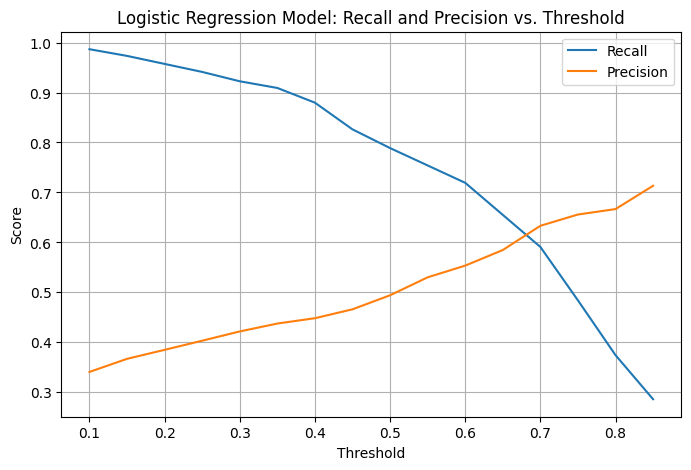

Threshold: 0.10, Recall: 0.99, Precision: 0.34
Threshold: 0.15, Recall: 0.97, Precision: 0.37
Threshold: 0.20, Recall: 0.96, Precision: 0.38
Threshold: 0.25, Recall: 0.94, Precision: 0.40
Threshold: 0.30, Recall: 0.92, Precision: 0.42
Threshold: 0.35, Recall: 0.91, Precision: 0.44
Threshold: 0.40, Recall: 0.88, Precision: 0.45
Threshold: 0.45, Recall: 0.83, Precision: 0.47
Threshold: 0.50, Recall: 0.79, Precision: 0.49
Threshold: 0.55, Recall: 0.75, Precision: 0.53
Threshold: 0.60, Recall: 0.72, Precision: 0.55


In [18]:
# Test probability thresholds for Logistic Regression Model

# Get predicted probabilities for positive class (predict_proba returns a 2D array: column 0 = probability of "no churn", column 1 = probability of "churn".)
y_proba_logreg = best_logreg.predict_proba(X_test_final)[:, 1]

thresholds = np.arange(0.1, 0.9, 0.05)
recalls = []
precisions = []

for thresh in thresholds:
    # Assign label of 1 ("churn") if predicted probability is >= to the threshold, else 0 ("no churn")
    y_pred = (y_proba_logreg >= thresh).astype(int)
    # Calculate recall for this threshold
    recalls.append(recall_score(y_test, y_pred))
    # Calculate precision for this threshold
    precisions.append(precision_score(y_test, y_pred))

# Plot recall and precision vs. threshold
# Create figure
plt.figure(figsize=(8,5))
# Plot recall values against thresholds
plt.plot(thresholds, recalls, label='Recall')
# Plot precision values against thresholds
plt.plot(thresholds, precisions, label='Precision')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Logistic Regression Model: Recall and Precision vs. Threshold')
plt.legend()
plt.grid(True)
plt.show()

# Find threshold for recall ≥ 0.70
for thresh, rec, prec in zip(thresholds, recalls, precisions):
    if rec >= 0.70:
        print(f"Threshold: {thresh:.2f}, Recall: {rec:.2f}, Precision: {prec:.2f}")

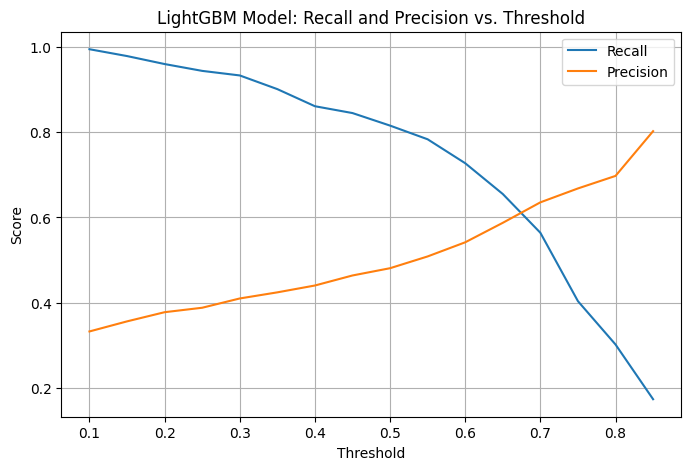

Threshold: 0.10, Recall: 0.99, Precision: 0.33
Threshold: 0.15, Recall: 0.98, Precision: 0.36
Threshold: 0.20, Recall: 0.96, Precision: 0.38
Threshold: 0.25, Recall: 0.94, Precision: 0.39
Threshold: 0.30, Recall: 0.93, Precision: 0.41
Threshold: 0.35, Recall: 0.90, Precision: 0.42
Threshold: 0.40, Recall: 0.86, Precision: 0.44
Threshold: 0.45, Recall: 0.84, Precision: 0.46
Threshold: 0.50, Recall: 0.82, Precision: 0.48
Threshold: 0.55, Recall: 0.78, Precision: 0.51
Threshold: 0.60, Recall: 0.73, Precision: 0.54


In [19]:
# Test probability thresholds for LightGBM model

# Get predicted probabilities for positive class (predict_proba returns a 2D array: column 0 = probability of "no churn", column 1 = probability of "churn".)
y_proba = final_lgbm.predict_proba(X_test_final)[:, 1]

# Create array of thresholds to test, i.e. 0.1 to 0.85 incremented by 0.05
thresholds = np.arange(0.1, 0.9, 0.05)
recalls = []
precisions = []

for thresh in thresholds:
    # Assign label of 1 ("churn") if predicted probability is >= to the threshold, else 0 ("no churn")
    y_pred = (y_proba >= thresh).astype(int)
    # Calculate recall for this threshold
    recalls.append(recall_score(y_test, y_pred))
    # Calculate precision for this threshold
    precisions.append(precision_score(y_test, y_pred))

# Plot recall and precision vs. threshold
# Create figure
plt.figure(figsize=(8,5))
# Plot recall values against thresholds
plt.plot(thresholds, recalls, label='Recall')
# Plot precision values against thresholds
plt.plot(thresholds, precisions, label='Precision')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('LightGBM Model: Recall and Precision vs. Threshold')
plt.legend()
plt.grid(True)
plt.show()

# Find threshold for recall ≥ 0.70
for thresh, rec, prec in zip(thresholds, recalls, precisions):
    if rec >= 0.70:
        print(f"Threshold: {thresh:.2f}, Recall: {rec:.2f}, Precision: {prec:.2f}")

In [21]:
# Logistic regression model confusion matrix

from sklearn.metrics import confusion_matrix

# Get predicted probabilities for positive class
y_proba_logreg = best_logreg.predict_proba(X_test_final)[:, 1]

# Apply 0.6 threshold to get predicted labels
y_pred_thresh = (y_proba_logreg >= 0.6).astype(int)

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred_thresh)
print(cm)

[[816 217]
 [105 269]]


In [22]:
# LightGBM model confusion matrix

# Get predicted probabilities for positive class
y_proba_lgbm = final_lgbm.predict_proba(X_test_final)[:, 1]

# Apply 0.6 threshold to get predicted labels
y_pred_thresh = (y_proba_lgbm >= 0.6).astype(int)

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred_thresh)
print(cm)

[[803 230]
 [102 272]]


### Model Selection Summary
After evaluating both the Logistic Regression and LightGBM models, the following key metrics were observed:

Logistic Regression:

Recall: X.XX
Precision: X.XX
ROC-AUC: X.XX
[Other relevant metrics or confusion matrix summary]
LightGBM:

Recall: X.XX
Precision: X.XX
ROC-AUC: X.XX
[Other relevant metrics or confusion matrix summary]
Comparison and Rationale:
[Discuss which metrics are most important for the business (e.g., prioritizing recall to minimize false negatives), and compare the models on these metrics. Mention any trade-offs, such as a slight drop in precision for a gain in recall.]

Final Model Choice:
Based on the evaluation, the [chosen model] was selected as the final model because [reason: e.g., it achieved the highest recall while maintaining acceptable precision and ROC-AUC, aligning with the business goal of identifying as many potential churners as possible].

In the next step, this model will be locked in, retrained on the full training data if needed, and final test set results will be reported.

## 6. Final Model Selection & Test Set Results
- Retrain final model on entire training dataset using best hyperparameters and preprocessing
- Evaluate on untouched test set
- Report final metrics (recall, precision, ROC-AUC, PR-AUC) and confidence intervals if feasible


In [ ]:
# Retrain 

## 7. Model Interpretation
- Global importance (permutation/impurity-based)
- Partial dependence / accumulated local effects (optional)
- Local explanations for case studies (e.g., SHAP) — optional
- Summarize what factors relate most to churn (business language)


## 8. Operationalization Artifacts
- Persist model and preprocessing pipeline (paths only)
- Prediction schema and expected inputs
- Simple inference example (no code here)


## 9. Reporting & Handoff
- Draft executive-friendly summary and technical appendix pointers
- Risks/assumptions and next steps (data collection, features, A/B test)
- Save selected figures to `reports/figures/` and export a short `reports/model_report.md`
